In [19]:
import pandas as pd
import numpy as np

# Evaluation Wording Only

In [20]:
import os
import pandas as pd

# dynamic path
notebook_dir = os.getcwd()
repo_root = os.path.abspath(os.path.join(notebook_dir, "..", ".."))

In [21]:
from scipy.spatial.distance import jensenshannon

In [22]:
def calculate_jsd_row(row):
    # get llm distribuations
    if pd.isna(row['LLM_Binary_Distribution']):
        return np.nan
    p = np.array([float(x) for x in row['LLM_Binary_Distribution'].split(',')])
    
    # get allbus distribuation
    pi_a = row['pi_ALLBUS']
    q = np.array([1.0 - pi_a, pi_a])

    js_metric = jensenshannon(p, q, base=2)
    return js_metric ** 2

In [23]:
def key_results_wording(dateiname):
    csv_path = os.path.join(repo_root, "results", dateiname)

    df_results_wording = pd.read_csv(csv_path, index_col="allbus_variable_variation")

    bias_v1 = df_results_wording['Bias_Direct'].iloc[0::3]
    bias_v2 = df_results_wording['Bias_Direct'].iloc[1::3]
    bias_v3 = df_results_wording['Bias_Direct'].iloc[2::3]
    
    mae_v1 = bias_v1.abs().mean()
    mae_v2 = bias_v2.abs().mean()
    mae_v3 = bias_v3.abs().mean()
    
    
    rmse_v1 = np.sqrt((bias_v1 ** 2).mean())
    rmse_v2 = np.sqrt((bias_v2 ** 2).mean())
    rmse_v3 = np.sqrt((bias_v3 ** 2).mean())

    df_results_wording['JSD_to_Human'] = df_results_wording.apply(calculate_jsd_row, axis=1)

    jsd_v1 = df_results_wording['JSD_to_Human'].iloc[0::3].mean()
    jsd_v2 = df_results_wording['JSD_to_Human'].iloc[1::3].mean()
    jsd_v3 = df_results_wording['JSD_to_Human'].iloc[2::3].mean()

    summary_data = {
        "Wording_Variante": ["v1", "v2", "v3"],
        "MAE": [mae_v1, mae_v2, mae_v3],
        "RMSE": [rmse_v1, rmse_v2, rmse_v3],
        "JSD_Mean": [jsd_v1, jsd_v2, jsd_v3]
    }
    summary_df = pd.DataFrame(summary_data)


    return df_results_wording, summary_df

    
key_results_wording("wording_results_llama.csv")[1]


,Wording_Variante,MAE,RMSE,JSD_Mean
0,v1,0.216540,0.278971,0.120984
1,v2,0.228057,0.265342,0.118509
2,v3,0.250078,0.301289,0.140469


In [24]:
key_results_wording("wording_results_llama.csv")[0]

,LLM_Mean,llm standard deviation,llm lower bound confidence interval,llm upper bound confidence interval,pi_Direct,pi_ALLBUS,LLM_Binary_Distribution,Valid_Runs,Invalid_Runs,Bias_Direct,LLM_Raw_Responses,JSD_to_Human
allbus_variable_variation,,,,,,,,,,,,
ma01b_v1,4.000000,0.000000,4.000000,4.000000,0.000000,0.669378,"1.0,0.0",30,0,-0.669378,"[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ...",0.461866
ma01b_v2,5.633333,0.490133,5.457942,5.808725,1.000000,0.669378,"0.0,1.0",30,0,0.330622,"[6, 6, 6, 5, 6, 5, 6, 5, 6, 5, 6, 6, 6, 5, 6, ...",0.189085
ma01b_v3,4.066667,0.253708,3.975878,4.157455,0.066667,0.669378,"0.9333333333333333,0.06666666666666667",30,0,-0.602712,"[4, 4, 4, 4, 4, 5, 4, 4, 4, 4, 4, 4, 4, 4, 5, ...",0.314682
ma02_v1,4.000000,0.000000,4.000000,4.000000,0.000000,0.146853,"1.0,0.0",30,0,-0.146853,"[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ...",0.077628
ma02_v2,1.000000,0.000000,1.000000,1.000000,0.000000,0.146853,"1.0,0.0",30,0,-0.146853,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0.077628
ma02_v3,4.000000,0.000000,4.000000,4.000000,0.000000,0.146853,"1.0,0.0",30,0,-0.146853,"[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ...",0.077628
ma03_v1,1.000000,0.000000,1.000000,1.000000,0.000000,0.187974,"1.0,0.0",30,0,-0.187974,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0.101033
ma03_v2,4.000000,0.000000,4.000000,4.000000,0.000000,0.187974,"1.0,0.0",29,1,-0.187974,"[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, ...",0.101033
ma03_v3,1.000000,0.000000,1.000000,1.000000,0.000000,0.187974,"1.0,0.0",30,0,-0.187974,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0.101033


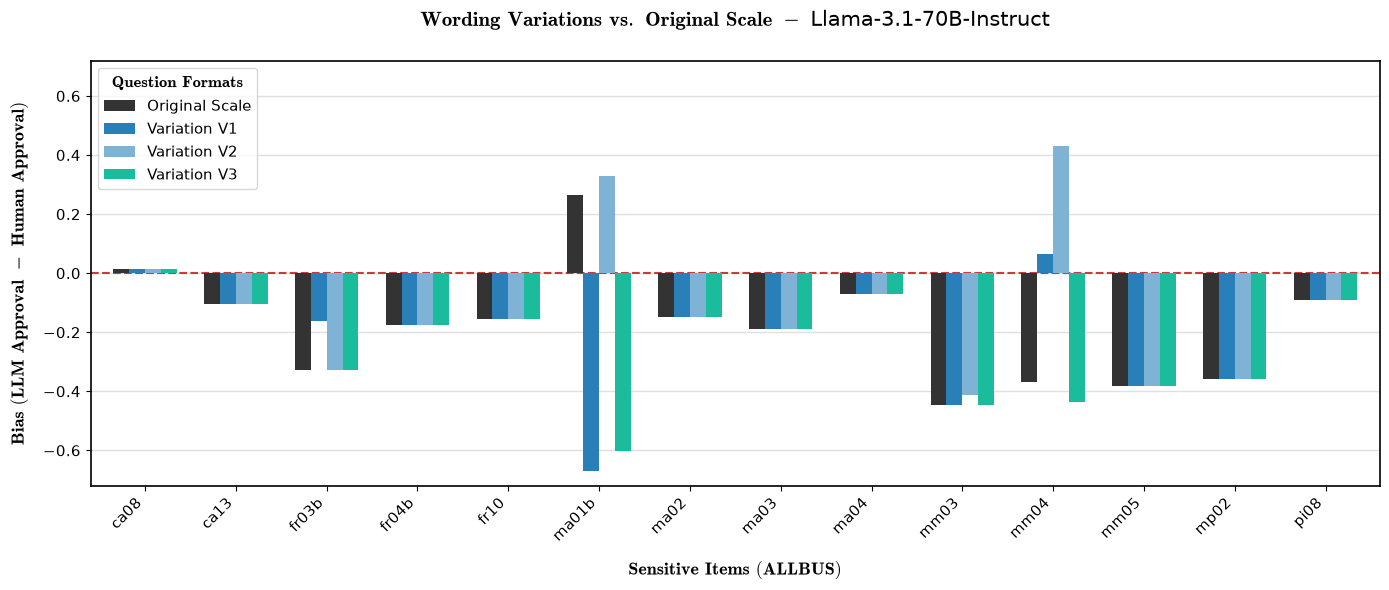

In [25]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings

def plot_wording_with_original_scale(base_file, wording_file, model_display_name, output_filename="wording_vs_original_bars.png"):


    warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",      
        "font.family": "sans-serif",    
        "font.sans-serif": ["DejaVu Sans"],
    })


    script_dir = os.path.dirname(os.path.abspath(__file__)) if "__file__" in locals() else os.getcwd()
    repo_root = os.path.abspath(os.path.join(script_dir, "..", ".."))
    
    path_base = os.path.join(repo_root, "results", base_file)
    path_wording = os.path.join(repo_root, "results", wording_file)
    
    if not os.path.exists(path_base) or not os.path.exists(path_wording):
        print(f"Fehler: Eine oder beide Dateien wurden nicht gefunden!\nBasis: {path_base}\nWording: {path_wording}")
        return


    df_base_raw = pd.read_csv(path_base)
    col_base_item = "allbus_variable" if "allbus_variable" in df_base_raw.columns else "allbus_variable_variation"
    col_base_bias = "Bias_Direct" if "Bias_Direct" in df_base_raw.columns else "Absolute_Bias"
    
    df_base = df_base_raw[[col_base_item, col_base_bias]].copy()
    df_base.columns = ["Item", "Bias_Direct"]
    df_base["Variation"] = "Original"

 
    df_word_raw = pd.read_csv(path_wording)
    col_word_item = "allbus_variable_variation" if "allbus_variable_variation" in df_word_raw.columns else "allbus_variable"
    col_word_bias = "Bias_Direct" if "Bias_Direct" in df_word_raw.columns else "Absolute_Bias"
    
    df_word = df_word_raw[[col_word_item, col_word_bias]].copy()
    

    df_word[['Item', 'Variation']] = df_word[col_word_item].astype(str).str.rsplit('_', n=1, expand=True)
    df_word = df_word[["Item", col_word_bias, "Variation"]].rename(columns={col_word_bias: "Bias_Direct"})


    df_combined = pd.concat([df_base, df_word], ignore_index=True)
    

    df_pivot = df_combined.pivot(index="Item", columns="Variation", values="Bias_Direct")
    df_pivot = df_pivot.sort_index()


    all_vars = df_pivot.columns.tolist()
    if "Original" in all_vars:
        all_vars.remove("Original")
        sorted_vars = ["Original"] + sorted(all_vars)
    else:
        sorted_vars = sorted(all_vars)


    plt.figure(figsize=(14, 6))
    ax = plt.gca()

    ax.set_facecolor("white")
    plt.grid(True, axis="y", color="#E0E0E0", linestyle="-", linewidth=1.0, zorder=1)

    x = np.arange(len(df_pivot))
    num_vars = len(sorted_vars)
    width = 0.7 / num_vars  

    # Farbpalette: Markantes Dunkelgrau für das echte Original-Format, Blautöne für Wording
    color_mapping = {
        "Original": "#333333",  # Der optische Anker der Grafik
        "v1": "#2980B9",
        "v2": "#7FB3D5",
        "v3": "#1ABC9C",
        "v4": "#9362BA"
    }

    for i, var in enumerate(sorted_vars):
        offset = (i - (num_vars - 1) / 2) * width
        color = color_mapping.get(var, "#95A5A6")
        label_name = "Original Scale" if var == "Original" else f"Variation {var.upper()}"
        
        
        plt.bar(
            x + offset, 
            df_pivot[var], 
            width, 
            label=label_name, 
            color=color, 
            zorder=3
        )

    plt.axhline(y=0, color="#C93B3B", linestyle="--", linewidth=1.5, zorder=2)

    plt.ylabel(r"$\mathbf{Bias\ (LLM\ Approval\ -\ Human\ Approval)}$", fontsize=13, labelpad=10)
    plt.xlabel(r"$\mathbf{Sensitive\ Items\ (ALLBUS)}$", fontsize=13, labelpad=12)

    plt.xticks(x, df_pivot.index, rotation=45, ha="right", fontsize=11)
    plt.yticks(fontsize=11)

    plt.xlim(-0.6, len(df_pivot) - 0.4)
    max_val = max(df_pivot.abs().max()) + 0.05
    plt.ylim(-max_val, max_val)

    for spine in ax.spines.values():
        spine.set_edgecolor("black")
        spine.set_linewidth(1.2)

    plt.legend(
        title=r"$\mathbf{Question\ Formats}$",
        title_fontsize="12",
        fontsize="11",
        loc="upper left",
        frameon=True,
        facecolor="white",
        edgecolor="#CCCCCC"
    )
    plt.title(fr"$\mathbf{{Wording\ Variations\ vs.\ Original\ Scale\ -}}$ {model_display_name}", fontsize=15, pad=25)
    plt.tight_layout()

    os.makedirs("plots", exist_ok=True)
    save_path = os.path.join("plots", output_filename)
    plt.savefig(save_path, dpi=300)
    
    plt.show()


if __name__ == "__main__":
    
    plot_wording_with_original_scale(
        base_file="bias_results_llama.csv",       
        wording_file="wording_results_llama.csv", 
        model_display_name="Llama-3.1-70B-Instruct", 
        output_filename="wording_vs_original_llama.png"
    )

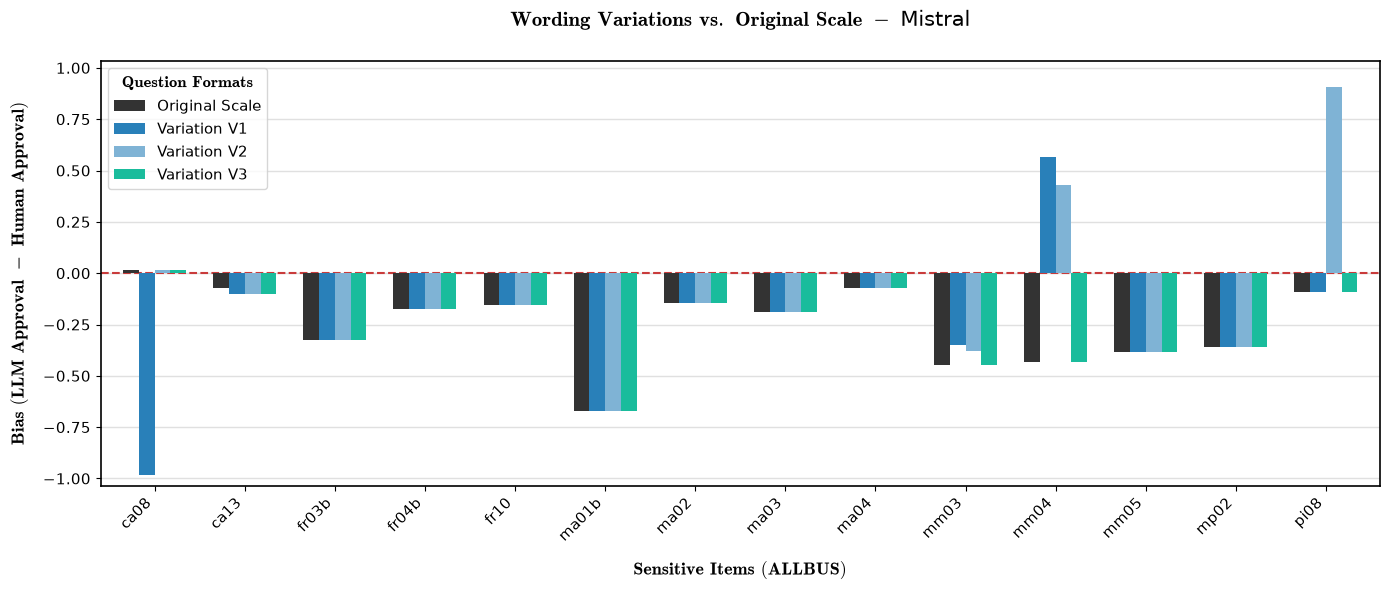

In [26]:
if __name__ == "__main__":
    
    plot_wording_with_original_scale(
        base_file="bias_results_mistral.csv",       
        wording_file="wording_results_mistral.csv", 
        model_display_name="Mistral", 
        output_filename="wording_vs_original_mistral.png"
    )

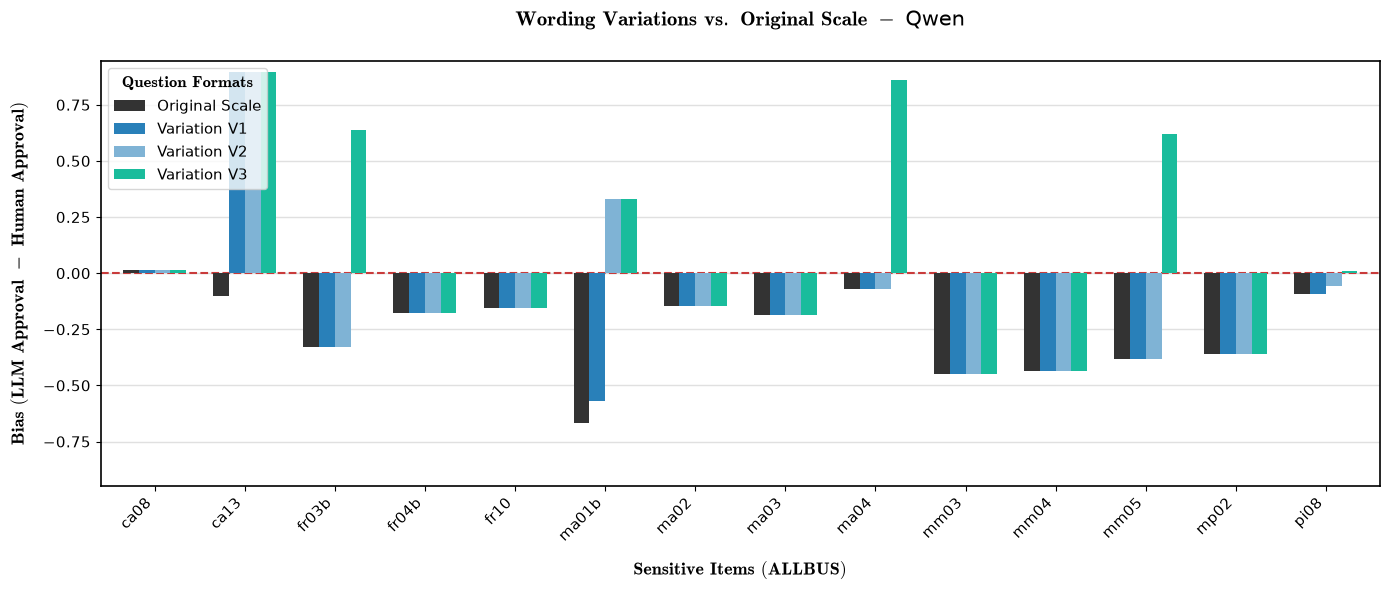

In [44]:
if __name__ == "__main__":
    
    plot_wording_with_original_scale(
        base_file="bias_results_qwen_2.csv",       
        wording_file="wording_results_qwen.csv", 
        model_display_name="Qwen", 
        output_filename="wording_vs_original_qwen.png"
    )

In [27]:
!pip install matplotlib

# Evaluation bias calculation

In [35]:
def key_results_bias(dateiname):

    csv_path = os.path.join(repo_root, "results", dateiname)

    df_results_bias = pd.read_csv(csv_path)

    bias = df_results_bias['Bias_Direct']
    mae = bias.abs().mean()
    rmse = np.sqrt((bias ** 2).mean())

    df_results_bias['JSD_to_Human'] = df_results_bias.apply(calculate_jsd_row, axis=1)

    jsd = df_results_bias['JSD_to_Human'].mean()

    #print(df_results_bias.columns)

    #self percieved position
    lr_self = df_results_bias['LLM mean mapped'].iloc[0]+df_results_bias['Self_Perception_Bias'].iloc[0]
    lr_self = np.round(df_results_bias['Self_Assessed_Mean_Baseline'].iloc[0],3)

    summary_data = {
        "MAE": [mae],
        "RMSE": [rmse],
        "JSD_Mean": [jsd],
        "self assesed position": [lr_self],
        "mean political position": [df_results_bias['LLM mean mapped'].mean()],
        "Absolute Bias (mean)": [df_results_bias['Absolute_Bias'].mean()]
    }

    return df_results_bias, pd.DataFrame(summary_data)

In [36]:
#df_results_bias = key_results_bias("bias_results.csv")[0]
#key_results = key_results_bias("bias_results.csv")[1]

In [37]:
def plot_bias_result(name_model, key_results_bias):

    llm_position = np.round(key_results_bias['mean political position'].iloc[0],2)
    lr_self = key_results_bias['self assesed position'].iloc[0]

    warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",      
        "font.family": "sans-serif",   
        "font.sans-serif": ["DejaVu Sans"],
    })
    
    plt.figure(figsize=(10, 3.5))
    ax = plt.gca()
    
    ax.set_facecolor("white")
    ax.get_yaxis().set_visible(False)
    
    
    plt.hlines(y=0, xmin=1, xmax=10, color="black", linewidth=2.5, zorder=1)
    
    
    ticks = list(range(1, 11))
    plt.xticks(ticks, [f"${t}$" for t in ticks], fontsize=13)
    plt.xlim(1, 10.)
    plt.ylim(-1.5, 1.5)
    
    plt.text(1, -0.5, "$\mathrm{Extreme\ Left}$\n$(1)$", ha="center", va="top", fontsize=11, color="#333333")
    plt.text(10, -0.5, "$\mathrm{Extreme\ Right}$\n$(10)$", ha="center", va="top", fontsize=11, color="#333333")
    
    
    plt.vlines(x=5.5, ymin=-0.1, ymax=0.1, color="#2C3E50", linestyle="-", linewidth=3, zorder=2)
    plt.plot(5.5, 0, marker="o", color="#2C3E50", markersize=8, zorder=3)
    plt.text(
        5.5, 0.15, r"$\mathbf{Political\ Center\ (5.5)}$", 
        ha="center", va="bottom", color="#2C3E50", fontsize=11
    )
    
    plt.plot(lr_self, 0, marker="o", color="#2980B9", markersize=9, zorder=4)
    plt.vlines(x=lr_self, ymin=-0.4, ymax=0, color="#2980B9", linestyle="--", linewidth=1.2, alpha=0.7)
    plt.text(
        lr_self, -0.45, rf"$\mathbf{{Self\ assessed\ position}}$" + f"\n$({lr_self})$", 
        ha="center", va="top", color="#2980B9", fontsize=11
    )
    
    plt.plot(llm_position, 0, marker="o", color="#E67E22", markersize=9, zorder=4)
    plt.vlines(x=llm_position, ymin=0, ymax=0.4, color="#E67E22", linestyle="--", linewidth=1.2, alpha=0.7)
    plt.text(
        llm_position, 0.45, rf"$\mathbf{{Calculated\ LLM\ position}}$" + f"\n$({llm_position})$", 
        ha="center", va="bottom", color="#E67E22", fontsize=11
    )
    
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_position(('data', 0))
    ax.spines['bottom'].set_color('black')
    ax.spines['bottom'].set_linewidth(1.5)
    
    
    plt.title(fr"$\mathbf{{Political\ Placement\ of\ {name_model}}}$", fontsize=15, pad=30)
    plt.tight_layout()

    os.makedirs("plots", exist_ok=True)
    plt.savefig(f"plots/llm_political_spectrum_ray_{name_model}.png", dpi=300)
    plt.show()

    
        

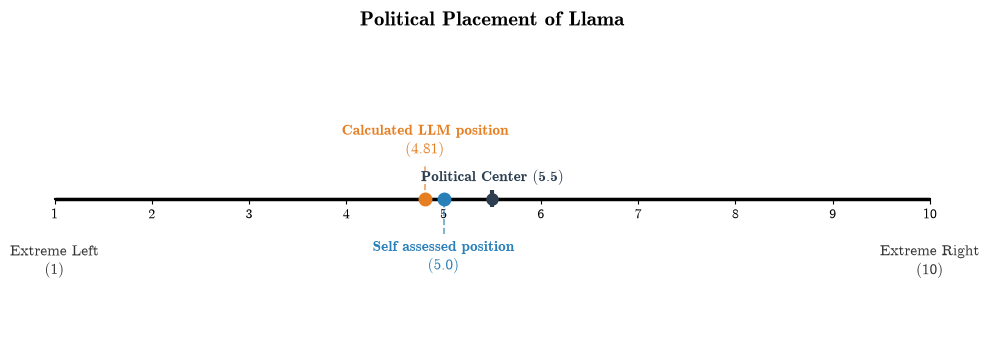

In [43]:
plot_bias_result("Llama", key_results_bias("results_bias_llama_2.csv")[1])

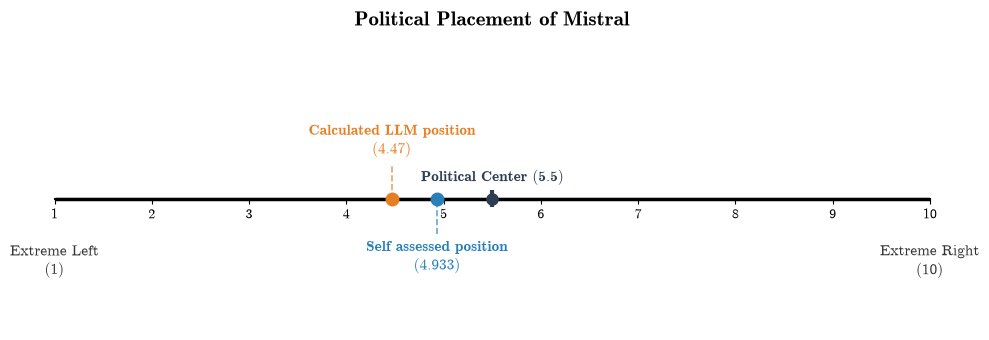

In [39]:
plot_bias_result("Mistral", key_results_bias("results_bias_mistral_2.csv")[1])

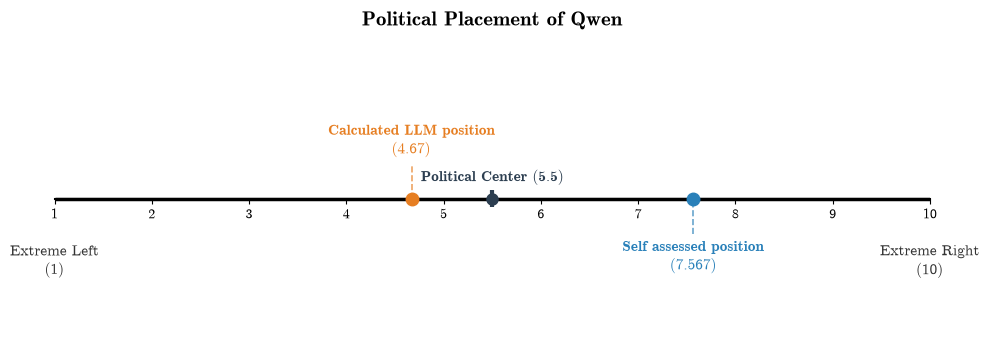

In [40]:
plot_bias_result("Qwen", key_results_bias("bias_results_qwen_2.csv")[1])

Erfolgreich gespeichert unter: plots/modell_vergleich.png


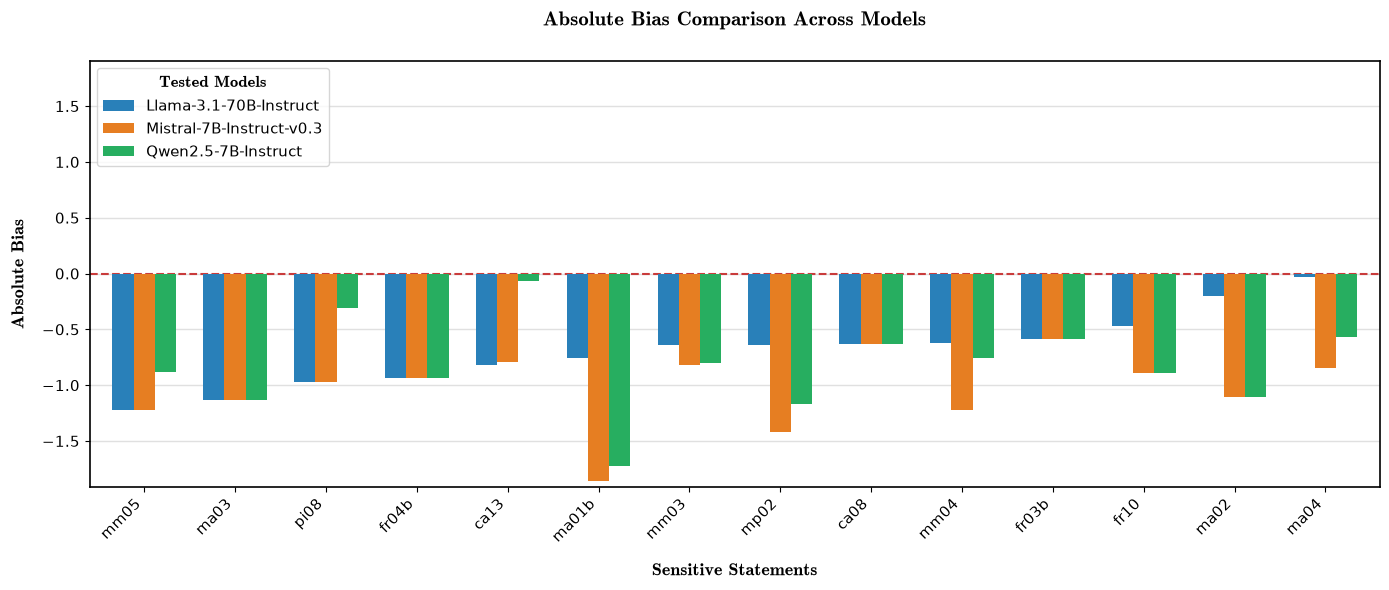

In [16]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings

def plot_multi_model_bias(file_names, output_filename="model_bias_comparison_bars.png"):

    warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",      
        "font.family": "sans-serif",    
        "font.sans-serif": ["DejaVu Sans"],
    })

    MERGE_COL = "allbus_variable"
    
    script_dir = os.path.dirname(os.path.abspath(__file__)) if "__file__" in locals() else os.getcwd()
    repo_root = os.path.abspath(os.path.join(script_dir, "..", ".."))


    NAME_MAPPING = {
        "LLAMA": "Llama-3.1-70B-Instruct",
        "MISTRAL": "Mistral-7B-Instruct-v0.3",
        "QWEN": "Qwen2.5-7B-Instruct"  # Schonmal vorbereitet für später!
    }

    loaded_dfs = []
    for dateiname in sorted(list(set(file_names))):
        csv_path = os.path.join(repo_root, "results", dateiname)
        
        if os.path.exists(csv_path):
            # Extrahiert z.B. "llama" oder "mistral"
            raw_name = dateiname.replace("bias_results_", "").replace(".csv", "").upper()
            
            # Schaut im Mapping nach. Wenn nicht gefunden, nimm den raw_name als Fallback
            model_name = NAME_MAPPING.get(raw_name, raw_name)
            
            df_temp = pd.read_csv(csv_path)[[MERGE_COL, "Absolute_Bias"]].rename(columns={"Absolute_Bias": model_name})
            loaded_dfs.append((model_name, df_temp))
        else:
            print(f"Hinweis: Datei nicht gefunden -> {csv_path}")

    if not loaded_dfs:
        print("Fehler: Keine der angegebenen CSV-Dateien wurde im Ordner 'results' gefunden!")
        return

    # Zusammenführen der echten Daten
    df_models = loaded_dfs[0][1]
    for name, df_next in loaded_dfs[1:]:
        df_models = df_models.merge(df_next, on=MERGE_COL)

    current_models = [name for name, _ in loaded_dfs]
    
    # Falls erst ein einziges Modell geladen werden konnte, füllen wir mit Dummys auf
    if len(current_models) == 1:
        base_model = current_models[0]
        df_models["Qwen-Dummy"] = df_models[base_model] + 0.08
        df_models["Mistral-Dummy"] = df_models[base_model] - 0.05
        model_columns = [base_model, "Qwen-Dummy", "Mistral-Dummy"]
    else:
        model_columns = current_models

    # Farbpalette dynamisch anpassen
    standard_colors = ["#2980B9", "#E67E22", "#27AE60", "#9362BA", "#F1C40F"]
    colors = standard_colors[:len(model_columns)]

    # Nach dem ersten Modell sortieren für die Treppenstruktur
    df_models = df_models.sort_values(by=model_columns[0]).reset_index(drop=True)

    plt.figure(figsize=(14, 6))
    ax = plt.gca()

    # Weißer Hintergrund mit hellem horizontalen Grid
    ax.set_facecolor("white")
    plt.grid(True, axis="y", color="#E0E0E0", linestyle="-", linewidth=1.0, zorder=1)

    x = np.arange(len(df_models))
    num_models = len(model_columns)
    width = 0.7 / num_models 

    for i, col_name in enumerate(model_columns):
        offset = (i - (num_models - 1) / 2) * width
        plt.bar(x + offset, df_models[col_name], width, label=col_name, color=colors[i], zorder=3)

    plt.axhline(y=0, color="#C93B3B", linestyle="--", linewidth=1.5, zorder=2)

    plt.ylabel(r"$\mathbf{Absolute\ Bias}$", fontsize=13, labelpad=10)
    plt.xlabel(r"$\mathbf{Sensitive\ Statements}$", fontsize=13, labelpad=12)

    plt.xticks(x, df_models[MERGE_COL], rotation=45, ha="right", fontsize=11)
    plt.yticks(fontsize=11)

    plt.xlim(-0.6, len(df_models) - 0.4)
    max_val = max(df_models[model_columns].abs().max()) + 0.05
    plt.ylim(-max_val, max_val)

    for spine in ax.spines.values():
        spine.set_edgecolor("black")
        spine.set_linewidth(1.2)

    plt.legend(
        title=r"$\mathbf{Tested\ Models}$",
        title_fontsize="12",
        fontsize="11",
        loc="upper left",
        frameon=True,
        facecolor="white",
        edgecolor="#CCCCCC"
    )
    plt.title(r"$\mathbf{Absolute\ Bias\ Comparison\ Across\ Models}$", fontsize=15, pad=25)
    plt.tight_layout()

    os.makedirs("plots", exist_ok=True)
    save_path = os.path.join("plots", output_filename)
    plt.savefig(save_path, dpi=300)
    print(f"Erfolgreich gespeichert unter: {save_path}")
    plt.show()


if __name__ == "__main__":
    aktuelle_files = [
        "bias_results_llama.csv",
        "bias_results_mistral.csv", 
        "bias_results_qwen.csv"      
    ]
    
    plot_multi_model_bias(file_names=aktuelle_files, output_filename="modell_vergleich.png")